# 06 — Explainability (SHAP)

Goal: move beyond "the model is 71% accurate" to "here's *why* this specific 
repo was flagged as high-risk" - the kind of explanation that turns a 
prediction into something a maintainer or team could actually act on, 
rather than a black-box score.

In [2]:
!pip install shap

In [3]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# reload the model-ready data and the trained full-feature model
data = joblib.load('../data/model_ready_data.pkl')
X_full_train = data['X_full_train']
X_full_test = data['X_full_test']
y_train = data['y_train']
y_test = data['y_test']

models = joblib.load('../models/random_forest_models.pkl')
rf_full = models['rf_full']

print("Loaded model and data.")
print("X_full_test shape:", X_full_test.shape)

In [4]:
explainer = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_full_test)

# shap_values shape depends on shap version - check it before using
print(type(shap_values))
if isinstance(shap_values, list):
    print(f"List of {len(shap_values)} arrays (one per class), each shape: {shap_values[0].shape}")
else:
    print("Array shape:", shap_values.shape)

<class 'numpy.ndarray'>
Array shape: (100, 34, 3)


In [5]:
print(rf_full.classes_)

['High' 'Low' 'Medium']


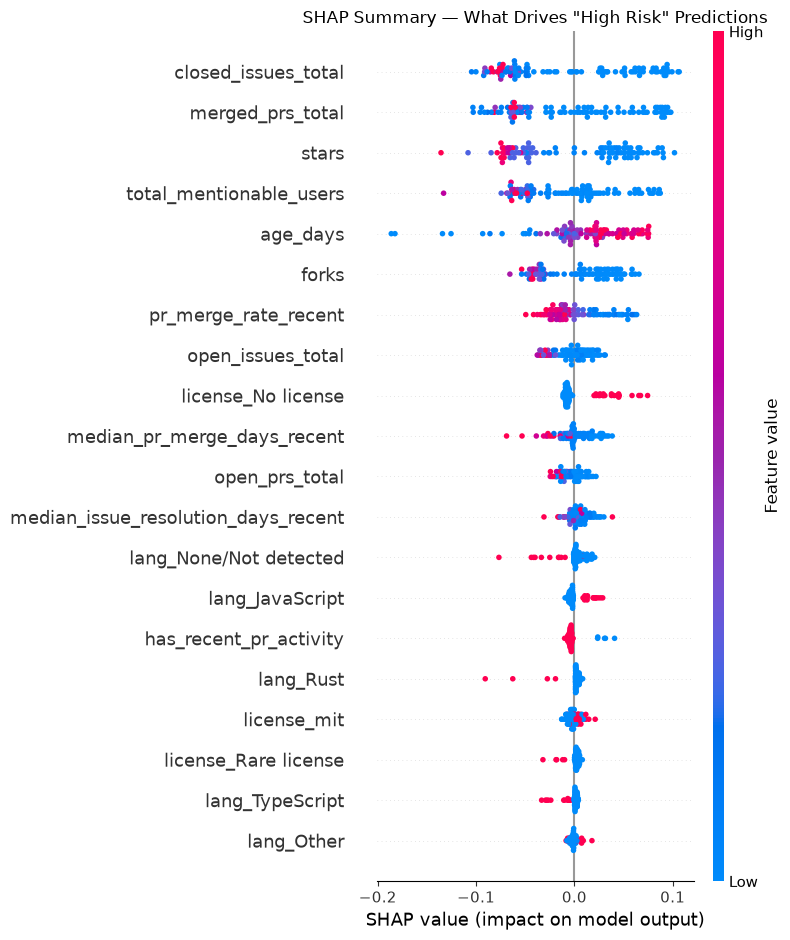

In [6]:
shap_values_high = shap_values[:, :, 0]  # High risk class

shap.summary_plot(shap_values_high, X_full_test, show=False)
plt.title('SHAP Summary — What Drives "High Risk" Predictions')
plt.tight_layout()
plt.show()

In [7]:
# find a repo the model confidently predicts as High risk
high_risk_probs = rf_full.predict_proba(X_full_test)[:, 0]  # index 0 = High
top_high_risk_idx = np.argsort(high_risk_probs)[-1]  # most confident High prediction

repo_idx_in_df = X_full_test.index[top_high_risk_idx]
print("Repo (by row index):", repo_idx_in_df)
print("Predicted High-risk probability:", round(high_risk_probs[top_high_risk_idx], 3))
print("Actual label:", y_test.iloc[top_high_risk_idx])

Repo (by row index): 420
Predicted High-risk probability: 0.985
Actual label: High


In [8]:
df = pd.read_csv('../data/clean_labeled_repos.csv')
repo_row = df.loc[repo_idx_in_df]
print("Repo:", repo_row['repo'])
print("Stars:", repo_row['stars'])
print("Days since last commit:", repo_row['days_since_last_commit'])
print("Is archived:", repo_row['is_archived'])
print("Risk category:", repo_row['risk_category'])

Repo: myqianlan/antd-admin-boilerplate
Stars: 100
Days since last commit: 2210.0
Is archived: False
Risk category: High


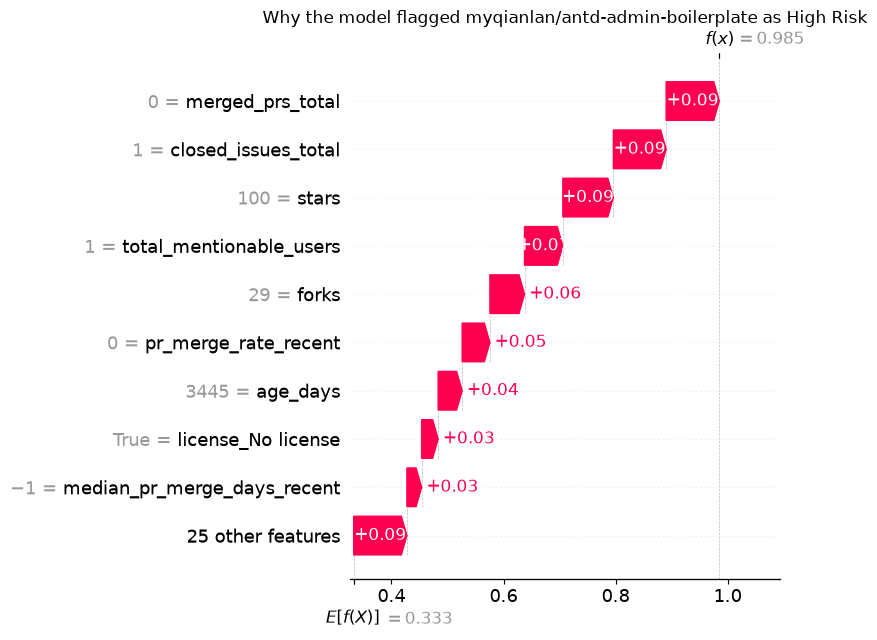

In [9]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_high[top_high_risk_idx],
        base_values=explainer.expected_value[0],
        data=X_full_test.iloc[top_high_risk_idx],
        feature_names=X_full_test.columns.tolist()
    ),
    show=False
)
plt.title(f"Why the model flagged {repo_row['repo']} as High Risk")
plt.tight_layout()
plt.show()

Repo: bevyengine/bevy
Predicted Low-risk probability: 0.97
Actual label: Low


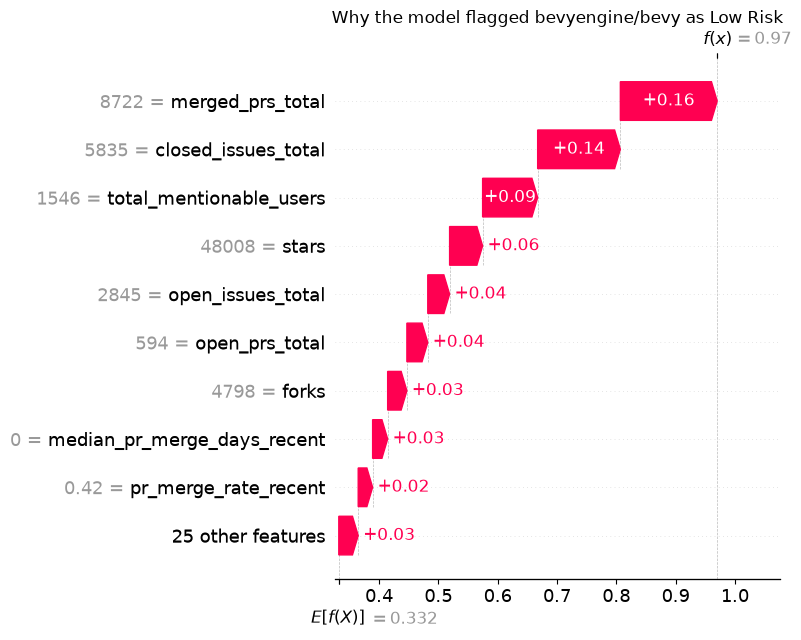

In [10]:
low_risk_probs = rf_full.predict_proba(X_full_test)[:, 1]  # index 1 = Low
top_low_risk_idx = np.argsort(low_risk_probs)[-1]
repo_idx_low = X_full_test.index[top_low_risk_idx]
repo_row_low = df.loc[repo_idx_low]

print("Repo:", repo_row_low['repo'])
print("Predicted Low-risk probability:", round(low_risk_probs[top_low_risk_idx], 3))
print("Actual label:", y_test.iloc[top_low_risk_idx])

shap_values_low = shap_values[:, :, 1]
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_low[top_low_risk_idx],
        base_values=explainer.expected_value[1],
        data=X_full_test.iloc[top_low_risk_idx],
        feature_names=X_full_test.columns.tolist()
    ),
    show=False
)
plt.title(f"Why the model flagged {repo_row_low['repo']} as Low Risk")
plt.tight_layout()
plt.show()

## Explainability Summary

SHAP analysis on the full-feature Random Forest model confirmed and 
extended earlier findings:

- **Cumulative activity volume** (`merged_prs_total`, `closed_issues_total`) 
  is the strongest driver - repos with a long track record of engagement 
  look safer to the model, independent of current activity level
- **License absence independently confirmed as a risk factor** via SHAP 
  attribution, matching the 2x risk gap found in SQL/EDA through a 
  completely different method
- **Repo age matters more in combination with other features than its 
  weak standalone correlation (+0.10) suggested** - an interaction effect 
  invisible to simple correlation analysis, only surfaced through the model
- **Individual predictions are fully explainable**: e.g. `myqianlan/antd-admin-boilerplate` 
  (100 stars, 6+ years dormant, never archived) flagged at 98.5% High-risk 
  confidence, with every contributing factor visualized; `bevyengine/bevy` 
  (48k stars, 8,722 merged PRs) flagged at 97% Low-risk confidence as a 
  contrasting example

**Next:** synthesize all findings (SQL + EDA + modeling + SHAP) into 
business recommendations, then build the dashboard/app layer.